# Analisis exploratorio de datos de los datasets en conjunto ENSO y ERA5

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

enso = pd.read_csv(
    DATA_PROCESSED / "enso_master.csv",
    parse_dates=["date"]
)

precip = pd.read_csv(
    DATA_PROCESSED / "ecuador_coast_precipitation.csv",
    parse_dates=["date"]
)

In [2]:
enso_precip = pd.merge(
    enso,
    precip,
    on="date",
    how="inner"
)

enso_precip.shape

(912, 10)

In [3]:
print(enso_precip["date"].min())
print(enso_precip["date"].max())
print(enso_precip.isna().sum())

1950-01-01 00:00:00
2025-12-01 00:00:00
date                  0
nino12                0
nino3                 0
nino34                0
nino4                 0
soi                   5
tni                   0
mei                 348
oni                   0
precipitation_mm      0
dtype: int64


la fecha minima y maxima se pudieron agrupar correctamente, tenemos 348 valores faltantes de mei ya que la caracteristica se contabiliza mucho despues

relacion contemporanea

In [4]:
variables = [
    "nino12",
    "nino3",
    "nino34",
    "nino4",
    "soi",
    "tni",
    "precipitation_mm"
]

enso_precip[variables].corr()["precipitation_mm"].sort_values()

soi                -0.164164
nino4               0.159044
nino34              0.230681
nino3               0.273768
tni                 0.273992
nino12              0.341916
precipitation_mm    1.000000
Name: precipitation_mm, dtype: float64

Relaciones de cada variable con la precipitacion

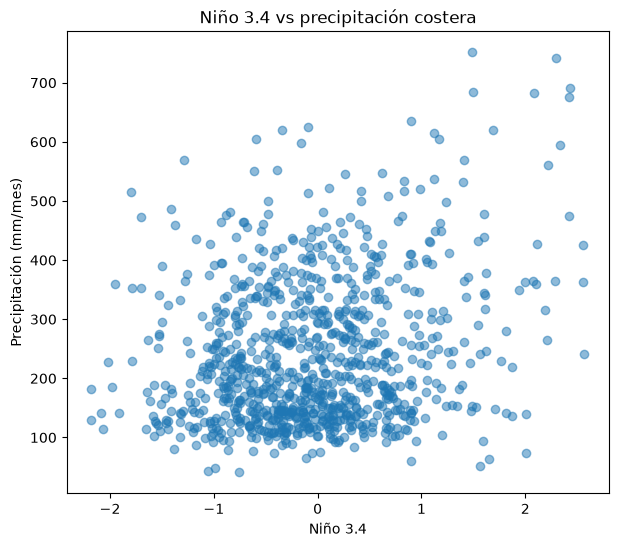

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    enso_precip["nino34"],
    enso_precip["precipitation_mm"],
    alpha=0.5
)

ax.set_xlabel("Niño 3.4")
ax.set_ylabel("Precipitación (mm/mes)")
ax.set_title("Niño 3.4 vs precipitación costera")

plt.show()

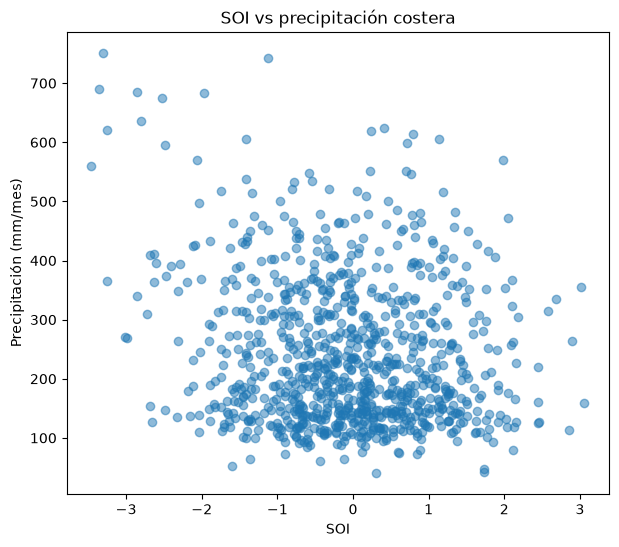

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    enso_precip["soi"],
    enso_precip["precipitation_mm"],
    alpha=0.5
)

ax.set_xlabel("SOI")
ax.set_ylabel("Precipitación (mm/mes)")
ax.set_title("SOI vs precipitación costera")

plt.show()

Relacion con ENSO adelantado

In [7]:
for lag in [0, 1, 2, 3, 6]:
    corr = (
        enso_precip["nino34"]
        .corr(
            enso_precip["precipitation_mm"].shift(-lag)
        )
    )

    print(f"Horizonte +{lag} meses: {corr:.3f}")

Horizonte +0 meses: 0.231
Horizonte +1 meses: 0.240
Horizonte +2 meses: 0.237
Horizonte +3 meses: 0.216
Horizonte +6 meses: 0.141


In [8]:
enso_variables = [
    "nino12",
    "nino3",
    "nino34",
    "nino4",
    "soi",
    "tni"
]

for variable in enso_variables:

    print(f"\n{variable.upper()}")

    for horizon in [0, 1, 2, 3, 6]:
        corr = enso_precip[variable].corr(
            enso_precip["precipitation_mm"].shift(-horizon)
        )

        print(
            f"+{horizon} meses: {corr:.3f}"
        )


NINO12
+0 meses: 0.342
+1 meses: 0.285
+2 meses: 0.238
+3 meses: 0.208
+6 meses: 0.228

NINO3
+0 meses: 0.274
+1 meses: 0.269
+2 meses: 0.259
+3 meses: 0.243
+6 meses: 0.195

NINO34
+0 meses: 0.231
+1 meses: 0.240
+2 meses: 0.237
+3 meses: 0.216
+6 meses: 0.141

NINO4
+0 meses: 0.159
+1 meses: 0.160
+2 meses: 0.148
+3 meses: 0.121
+6 meses: 0.057

SOI
+0 meses: -0.164
+1 meses: -0.171
+2 meses: -0.168
+3 meses: -0.149
+6 meses: -0.144

TNI
+0 meses: 0.274
+1 meses: 0.275
+2 meses: 0.244
+3 meses: 0.192
+6 meses: 0.056


Problema de la estacionalidad: Anomalia de precipitacion

In [9]:
enso_precip["month"] = enso_precip["date"].dt.month

monthly_climatology = (
    enso_precip
    .groupby("month")["precipitation_mm"]
    .transform("mean")
)

In [10]:
enso_precip["precip_anomaly"] = (
    enso_precip["precipitation_mm"]
    - monthly_climatology
)

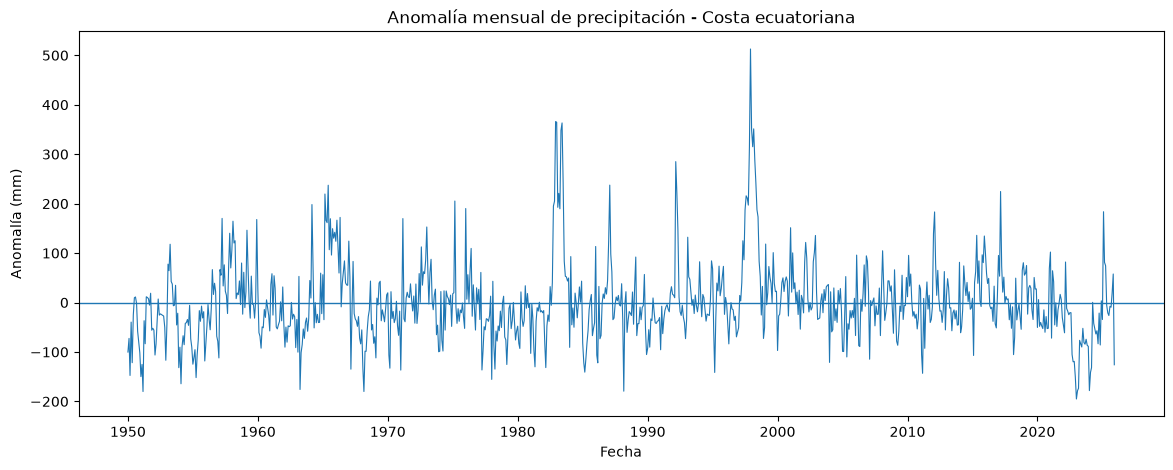

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    enso_precip["date"],
    enso_precip["precip_anomaly"],
    linewidth=0.8
)

ax.axhline(0, linewidth=1)

ax.set_title(
    "Anomalía mensual de precipitación - Costa ecuatoriana"
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Anomalía (mm)")

plt.show()

+ de 200 mm es un mes mucho mas humedo de lo habitual y - de 100 mm es mas seco de lo habitual

Correlaciones utilizando las anomalias

In [12]:
for horizon in [0, 1, 2, 3, 6]:
    corr = enso_precip["nino34"].corr(
        enso_precip["precip_anomaly"].shift(-horizon)
    )

    print(
        f"Niño 3.4 → precip anomaly +{horizon}: "
        f"{corr:.3f}"
    )

Niño 3.4 → precip anomaly +0: 0.358
Niño 3.4 → precip anomaly +1: 0.366
Niño 3.4 → precip anomaly +2: 0.354
Niño 3.4 → precip anomaly +3: 0.320
Niño 3.4 → precip anomaly +6: 0.213


In [13]:
for variable in enso_variables:

    print(f"\n{variable.upper()}")

    for horizon in [0, 1, 2, 3, 6]:
        corr = enso_precip[variable].corr(
            enso_precip["precip_anomaly"].shift(-horizon)
        )

        print(
            f"+{horizon} meses: {corr:.3f}"
        )


NINO12
+0 meses: 0.549
+1 meses: 0.499
+2 meses: 0.448
+3 meses: 0.403
+6 meses: 0.321

NINO3
+0 meses: 0.449
+1 meses: 0.435
+2 meses: 0.410
+3 meses: 0.373
+6 meses: 0.267

NINO34
+0 meses: 0.358
+1 meses: 0.366
+2 meses: 0.354
+3 meses: 0.320
+6 meses: 0.213

NINO4
+0 meses: 0.204
+1 meses: 0.222
+2 meses: 0.222
+3 meses: 0.201
+6 meses: 0.134

SOI
+0 meses: -0.231
+1 meses: -0.272
+2 meses: -0.299
+3 meses: -0.293
+6 meses: -0.229

TNI
+0 meses: 0.318
+1 meses: 0.305
+2 meses: 0.275
+3 meses: 0.237
+6 meses: 0.188


Comparacion de ENSO con las anomalias

In [14]:
comparison = enso_precip[
    ["date", "nino34", "precip_anomaly"]
].copy()

comparison["nino34_z"] = (
    comparison["nino34"]
    - comparison["nino34"].mean()
) / comparison["nino34"].std()

comparison["precip_z"] = (
    comparison["precip_anomaly"]
    - comparison["precip_anomaly"].mean()
) / comparison["precip_anomaly"].std()

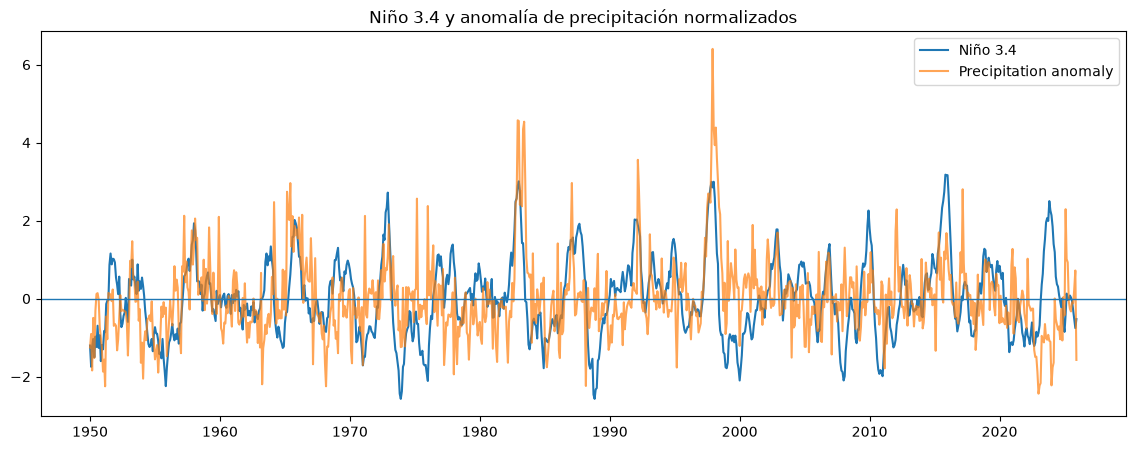

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    comparison["date"],
    comparison["nino34_z"],
    label="Niño 3.4"
)

ax.plot(
    comparison["date"],
    comparison["precip_z"],
    label="Precipitation anomaly",
    alpha=0.7
)

ax.axhline(0, linewidth=1)

ax.legend()
ax.set_title(
    "Niño 3.4 y anomalía de precipitación normalizados"
)

plt.show()

Guardar set de datos enso_precip en data/processed

In [16]:
# guardar set de datos enso_precip en data/processed

enso_precip.to_csv(
    DATA_PROCESSED / "enso_precip.csv",
    index=False
)
